# Email Phishing Detection - Data Analytics

This notebook performs exploratory data analysis (EDA), feature engineering, and predictive modeling on the provided phishing email dataset.

In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('phishing_email_detection_2026_dataset.csv')

# Basic inspection
display(df.head())
display(df.info())
display(df.describe())


,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
0,1,harrisonsandra@paypal-alert.com,Meeting Reminder,0,1,2,0,227,0
1,2,randyharris@bankverify.net,Urgent Account Verification,1,1,9,7,59,1
2,3,adam13@outlook.com,Suspicious Login Attempt,1,1,8,10,67,1
3,4,kennethfisher@company-secure.com,Suspicious Login Attempt,0,1,9,8,102,1
4,5,wsandoval@paypal-alert.com,Your Password Will Expire,1,0,7,4,96,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   email_id            1500 non-null   int64 
 1   sender_email        1500 non-null   object
 2   subject             1500 non-null   object
 3   has_link            1500 non-null   int64 
 4   has_attachment      1500 non-null   int64 
 5   urgency_score       1500 non-null   int64 
 6   spelling_errors     1500 non-null   int64 
 7   email_length_words  1500 non-null   int64 
 8   is_phishing         1500 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 105.6+ KB


None

,email_id,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,0.629333,0.512667,5.722667,3.708000,132.559333,0.493333
std,433.157015,0.483144,0.500006,3.002182,3.209819,79.315970,0.500122
min,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,0.000000
25%,375.750000,0.000000,0.000000,3.000000,1.000000,72.000000,0.000000
50%,750.500000,1.000000,1.000000,5.000000,2.000000,108.000000,0.000000
75%,1125.250000,1.000000,1.000000,8.000000,6.000000,193.000000,1.000000
max,1500.000000,1.000000,1.000000,10.000000,10.000000,300.000000,1.000000


In [264]:
df.tail()

,email_id,sender_email,subject,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
1495,1496,villabrian@gmail.com,Claim Your Reward Now,1,1,8,7,113,1
1496,1497,lharvey@gmail.com,Urgent Account Verification,1,0,8,5,50,1
1497,1498,xjennings@outlook.com,Suspicious Login Attempt,0,0,8,10,82,1
1498,1499,paulcobb@paypal-alert.com,Suspicious Login Attempt,1,0,7,9,36,1
1499,1500,kristen14@company-secure.com,Invoice Attached,0,1,4,0,161,0


In [265]:
# Target variable distribution
display(df['is_phishing'].value_counts())
display(df['is_phishing'].value_counts(normalize=True))  # Percentages

# Feature ranges
print(df[['has_link', 'has_attachment', 'urgency_score', 'spelling_errors', 'email_length_words']].describe())

# Unique senders and subjects
display(f"Unique senders: {df['sender_email'].nunique()}")
display(f"Unique subjects: {df['subject'].nunique()}")


is_phishing
0    760
1    740
Name: count, dtype: int64

is_phishing
0    0.506667
1    0.493333
Name: proportion, dtype: float64

          has_link  has_attachment  urgency_score  spelling_errors  \
count  1500.000000     1500.000000    1500.000000      1500.000000   
mean      0.629333        0.512667       5.722667         3.708000   
std       0.483144        0.500006       3.002182         3.209819   
min       0.000000        0.000000       1.000000         0.000000   
25%       0.000000        0.000000       3.000000         1.000000   
50%       1.000000        1.000000       5.000000         2.000000   
75%       1.000000        1.000000       8.000000         6.000000   
max       1.000000        1.000000      10.000000        10.000000   

       email_length_words  
count         1500.000000  
mean           132.559333  
std             79.315970  
min             20.000000  
25%             72.000000  
50%            108.000000  
75%            193.000000  
max            300.000000  


'Unique senders: 1499'

'Unique subjects: 10'

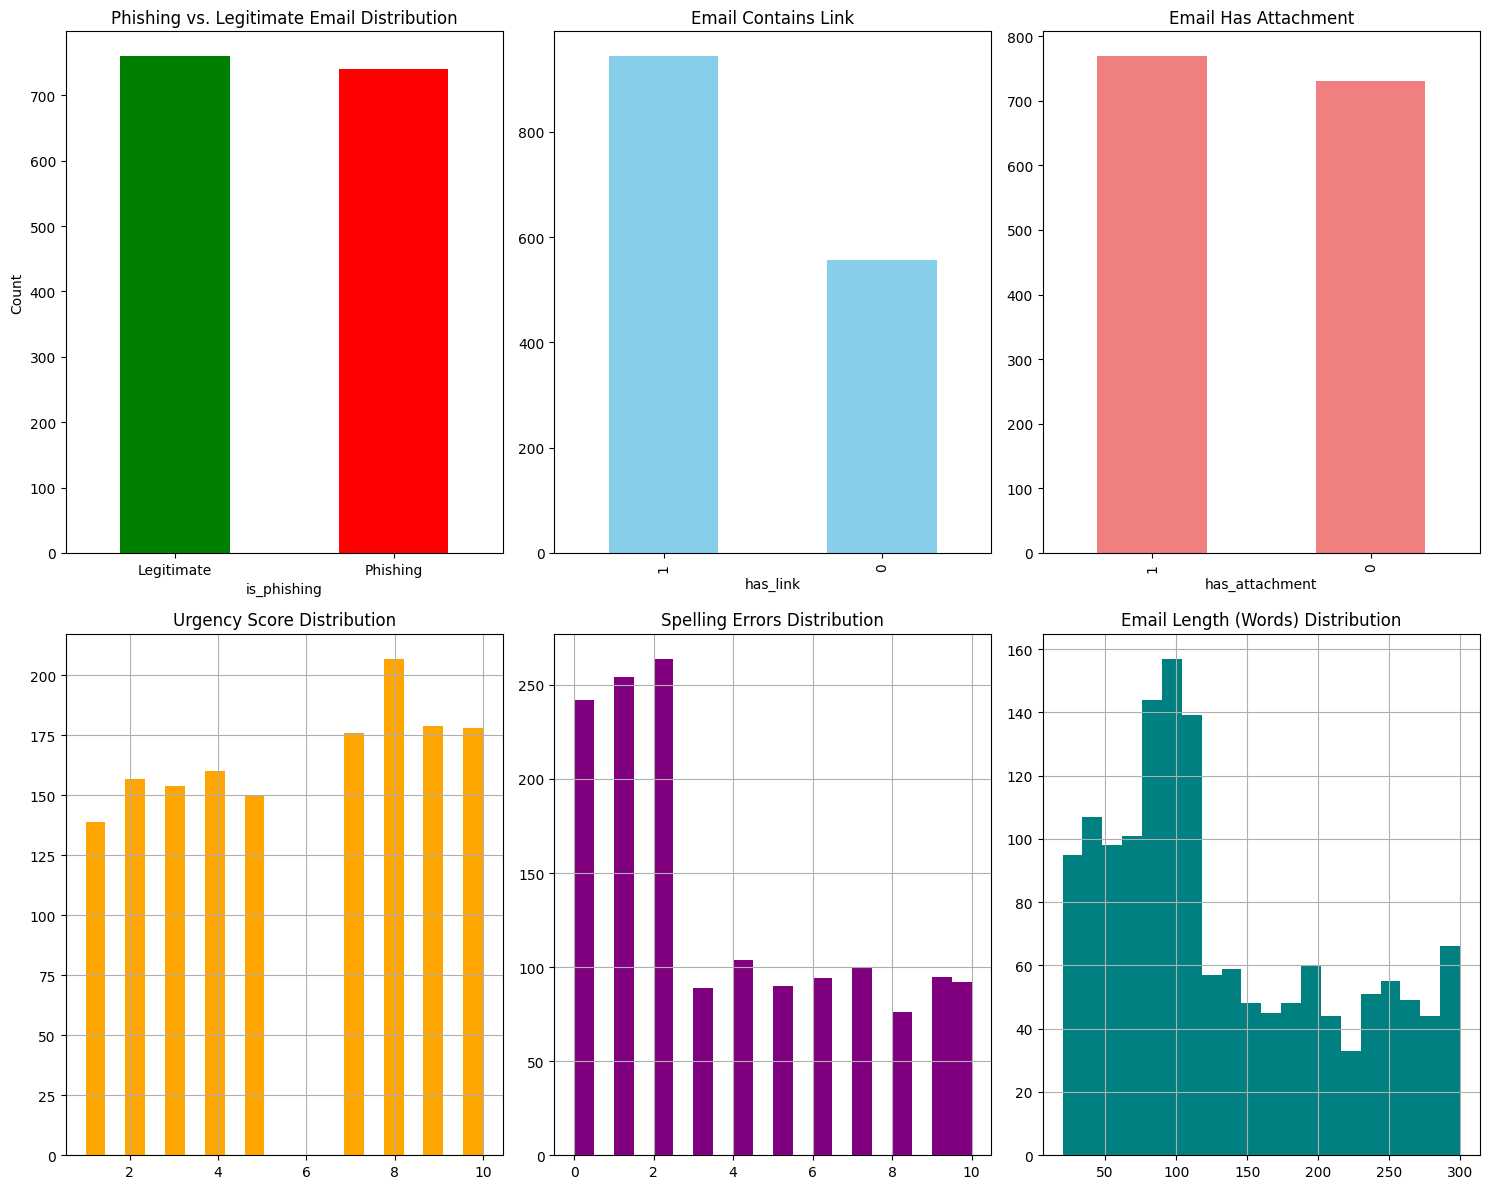

In [266]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 12))

# Target variable
df['is_phishing'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Phishing vs. Legitimate Email Distribution')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Legitimate', 'Phishing'], rotation=0)

# Binary features
df['has_link'].value_counts().plot(kind='bar', ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Email Contains Link')

df['has_attachment'].value_counts().plot(kind='bar', ax=axes[0,2], color='lightcoral')
axes[0,2].set_title('Email Has Attachment')

# Numerical features - distributions
df['urgency_score'].hist(ax=axes[1,0], bins=20, color='orange')
axes[1,0].set_title('Urgency Score Distribution')

df['spelling_errors'].hist(ax=axes[1,1], bins=20, color='purple')
axes[1,1].set_title('Spelling Errors Distribution')

df['email_length_words'].hist(ax=axes[1,2], bins=20, color='teal')
axes[1,2].set_title('Email Length (Words) Distribution')

plt.tight_layout()
plt.show()


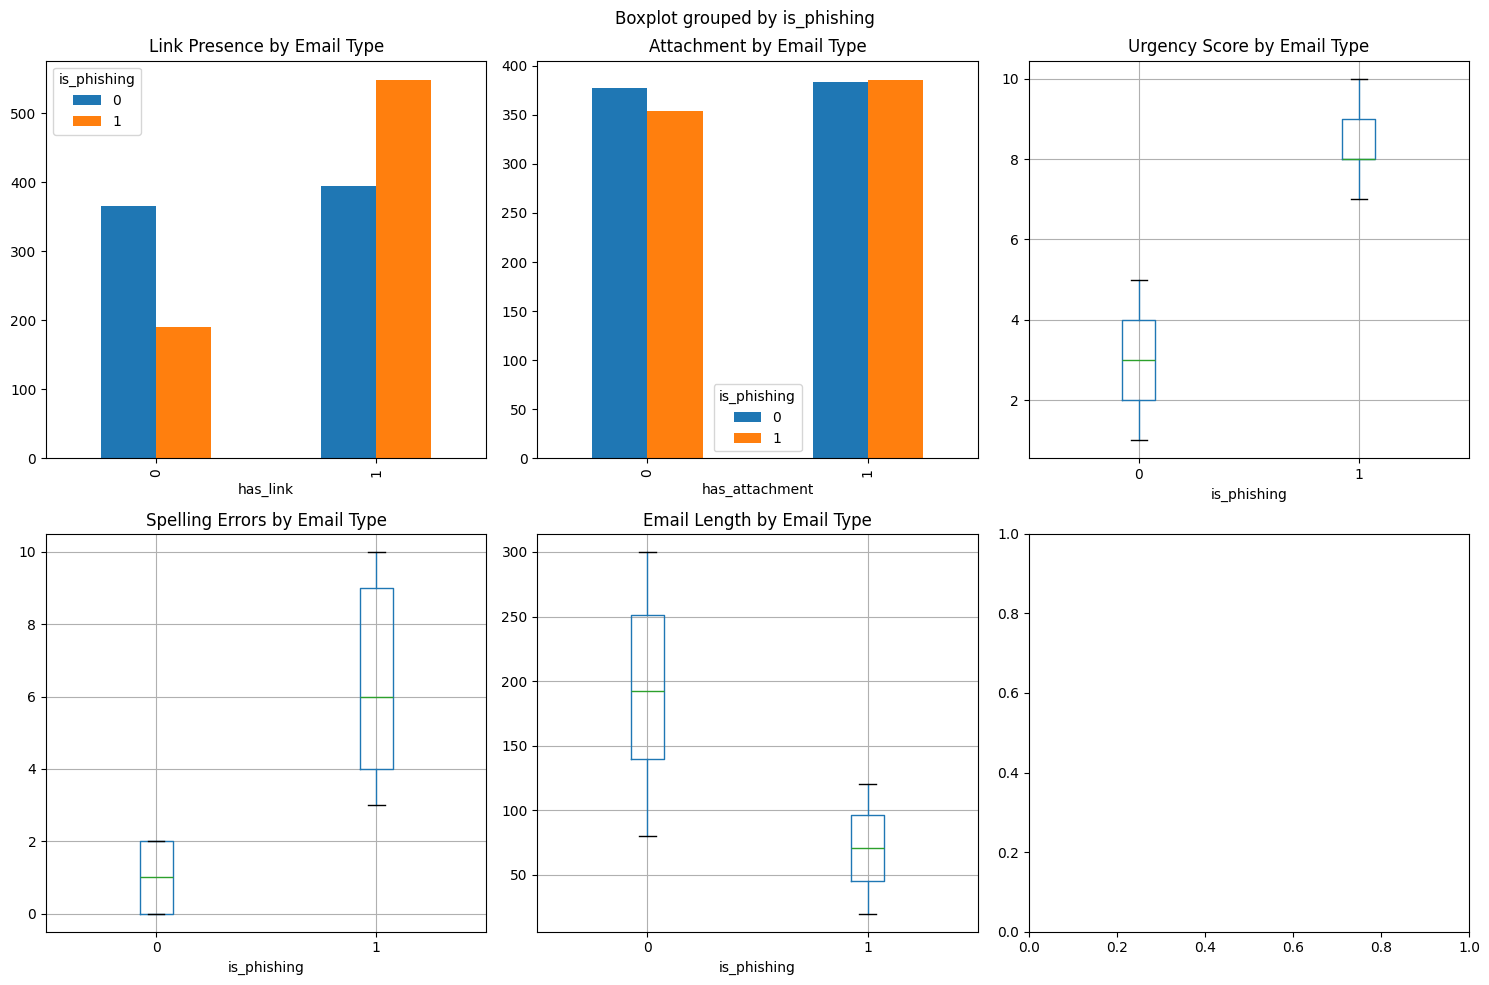

In [267]:
# How do features differ between phishing and legitimate emails?
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Phishing vs. Link presence
pd.crosstab(df['has_link'], df['is_phishing']).plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Link Presence by Email Type')

# Phishing vs. Attachment
pd.crosstab(df['has_attachment'], df['is_phishing']).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Attachment by Email Type')

# Box plots for continuous features
df.boxplot(column='urgency_score', by='is_phishing', ax=axes[0,2])
axes[0,2].set_title('Urgency Score by Email Type')

df.boxplot(column='spelling_errors', by='is_phishing', ax=axes[1,0])
axes[1,0].set_title('Spelling Errors by Email Type')

df.boxplot(column='email_length_words', by='is_phishing', ax=axes[1,1])
axes[1,1].set_title('Email Length by Email Type')

plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [268]:
# Analyze sender domains
df['sender_domain'] = df['sender_email'].str.split('@').str[1]
display(df['sender_domain'].value_counts().head(10))


sender_domain
gmail.com             314
outlook.com           306
paypal-alert.com      304
company-secure.com    299
bankverify.net        277
Name: count, dtype: int64

In [269]:
# Subject analysis (common words in phishing vs. legitimate)
phishing_subjects = df[df['is_phishing'] == 1]['subject']
display(phishing_subjects.head(15))

legitimate_subjects = df[df['is_phishing'] == 0]['subject']
display(legitimate_subjects.head(15))

1     Urgent Account Verification
2        Suspicious Login Attempt
3        Suspicious Login Attempt
4       Your Password Will Expire
5           Claim Your Reward Now
7     Urgent Account Verification
11            Bank Account Locked
15          Claim Your Reward Now
16    Urgent Account Verification
19            Bank Account Locked
20            Bank Account Locked
23          Claim Your Reward Now
24    Urgent Account Verification
25            Bank Account Locked
27       Suspicious Login Attempt
Name: subject, dtype: object

0       Meeting Reminder
6     Interview Schedule
8       Invoice Attached
9       Invoice Attached
10        Project Update
12      Meeting Reminder
13        Project Update
14    Interview Schedule
17    Interview Schedule
18      Meeting Reminder
21        Project Update
22        Project Update
26      Invoice Attached
30        Project Update
32      Invoice Attached
Name: subject, dtype: object

In [270]:
display("Top 10 common words in phishing email subjects:")
phishing_words = ' '.join(phishing_subjects).lower().split()
phishing_word_freq = pd.Series(phishing_words).value_counts()
display(phishing_word_freq.head(10))

'Top 10 common words in phishing email subjects:'

your          299
account       279
claim         167
reward        167
now           167
suspicious    162
login         162
attempt       162
bank          152
locked        152
Name: count, dtype: int64

In [271]:
# Extract domain from email
df['sender_domain'] = df['sender_email'].apply(lambda x: x.split('@')[-1] if pd.notnull(x) else 'Unknown')

# Top 10 domains with highest phishing percentage (with at least 10 emails)
domain_stats = df.groupby('sender_domain').agg(
    total_emails=('email_id', 'count'),
    phishing_count=('is_phishing', 'sum')
)
domain_stats['phishing_rate'] = domain_stats['phishing_count'] / domain_stats['total_emails']

display(domain_stats[domain_stats['total_emails'] >= 10].sort_values(by='phishing_rate', ascending=False).head(10))

,total_emails,phishing_count,phishing_rate
sender_domain,,,
outlook.com,306,157,0.513072
bankverify.net,277,141,0.509025
company-secure.com,299,147,0.491639
gmail.com,314,153,0.487261
paypal-alert.com,304,142,0.467105


In [272]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate email_ids: {df['email_id'].duplicated().sum()}")

# Check for outliers using IQR method
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Check each numerical feature
for col in ['urgency_score', 'spelling_errors', 'email_length_words']:
    outliers = find_outliers(df, col)
    print(f"\n{col} outliers: {len(outliers)}")


Duplicate rows: 0
Duplicate email_ids: 0

urgency_score outliers: 0

spelling_errors outliers: 0

email_length_words outliers: 0


In [273]:
# From sender_email
df['sender_domain'] = df['sender_email'].str.split('@').str[1]
# Correct logic: public domains are safe; domains containing phishing keywords are suspicious
df['is_suspicious_domain'] = df['sender_domain'].str.contains('alert|verify|secure', case=False, na=False).astype(int)

# From subject
df['subject_length'] = df['subject'].str.split().str.len()
# Correct logic: match actual phishing keywords found in the dataset to improve feature representation
df['has_urgency_keywords'] = df['subject'].str.lower().str.contains(
    'urgent|confirm|verify|verification|suspicious|login|attempt|password|expire|claim|reward|locked',
    regex=True,
    na=False
).astype(int)

# Combine features (EDA heuristic)
df['suspicious_score'] = (df['urgency_score'] + 
                          df['spelling_errors'] + 
                          df['has_link'] + 
                          df['is_suspicious_domain'])

# Print new features
df[['sender_domain', 'is_suspicious_domain', 'subject_length', 
          'has_urgency_keywords', 'suspicious_score']].head(10)


,sender_domain,is_suspicious_domain,subject_length,has_urgency_keywords,suspicious_score
0,paypal-alert.com,1,2,0,3
1,bankverify.net,1,3,1,18
2,outlook.com,0,3,1,19
3,company-secure.com,1,3,1,18
4,paypal-alert.com,1,4,1,13
5,company-secure.com,1,4,1,15
6,gmail.com,0,2,0,4
7,paypal-alert.com,1,3,1,22
8,gmail.com,0,2,0,8
9,bankverify.net,1,2,0,7


In [274]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Create a copy for modeling
df_model = df.copy()

# Drop non-predictive columns and suspicious_score (to prevent multicollinearity)
df_model = df_model.drop(['email_id', 'sender_email', 'subject', 'sender_domain', 'suspicious_score'], axis=1)

# Features and target
X = df_model.drop('is_phishing', axis=1)
y = df_model['is_phishing']

print("Features selected for modeling:", list(X.columns))


Features selected for modeling: ['has_link', 'has_attachment', 'urgency_score', 'spelling_errors', 'email_length_words', 'is_suspicious_domain', 'subject_length', 'has_urgency_keywords']


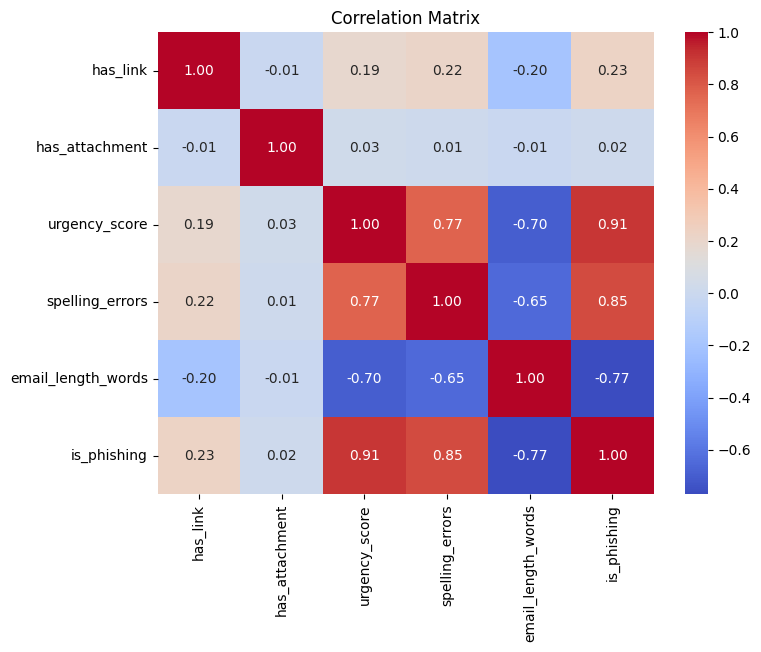

In [275]:
# Correlation heatmap
numerical_cols = ['has_link', 'has_attachment', 'urgency_score', 'spelling_errors', 'email_length_words', 'is_phishing']
corr = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Class distribution:
is_phishing
0    760
1    740
Name: count, dtype: int64

Percentages:
is_phishing
0    50.666667
1    49.333333
Name: proportion, dtype: float64


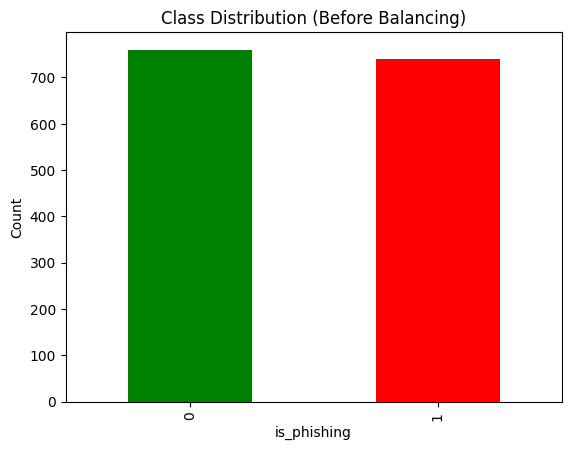

In [276]:
print("Class distribution:")
print(y.value_counts())
print("\nPercentages:")
print(y.value_counts(normalize=True) * 100)

# Visualize
y.value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution (Before Balancing)')
plt.ylabel('Count')
plt.show()


In [277]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Stratified split (maintains class proportions)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Ensures both sets have same class distribution
)

# Scale training data and test data separately to prevent data leakage
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")


Training set: 1200 samples
Test set: 300 samples

Training set class distribution:
is_phishing
0    608
1    592
Name: count, dtype: int64

Test set class distribution:
is_phishing
0    152
1    148
Name: count, dtype: int64


In [278]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Check if imbalance exists
imbalance_ratio = y_train.value_counts()[1] / y_train.value_counts()[0]
print(f"Imbalance ratio: {imbalance_ratio:.2%}")

if imbalance_ratio < 0.3:  # Severe imbalance
    # Use SMOTE to oversample minority class
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print(f"\nAfter SMOTE balancing:")
    print(f"Training set size: {len(X_train_balanced)}")
    print(y_train_balanced.value_counts())
else:
    X_train_balanced = X_train
    y_train_balanced = y_train


Imbalance ratio: 97.37%


In [279]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Dictionary of models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    
    # Store predictions for later evaluation
    results[name] = {
        'model': model,
        'y_pred': y_pred
    }
    
    print(f"\n{name} trained successfully")



Logistic Regression trained successfully

Naive Bayes trained successfully

KNN (k=5) trained successfully

Decision Tree trained successfully

Random Forest trained successfully

Gradient Boosting trained successfully

XGBoost trained successfully

SVM trained successfully


In [280]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# Tune Random Forest
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',  # Use F1 for imbalanced data
    n_jobs=-1
)

rf_grid.fit(X_train_balanced, y_train_balanced)
print(f"Best Random Forest parameters: {rf_grid.best_params_}")
print(f"Best cross-validation F1 score: {rf_grid.best_score_:.4f}")

# Tune XGBoost
xgb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train_balanced, y_train_balanced)
print(f"\nBest XGBoost parameters: {xgb_grid.best_params_}")
print(f"Best cross-validation F1 score: {xgb_grid.best_score_:.4f}")

# Update results dictionary with the best tuned models to include them in evaluation comparison
results['Random Forest (Tuned)'] = {
    'model': rf_grid.best_estimator_,
    'y_pred': rf_grid.best_estimator_.predict(X_test)
}
results['XGBoost (Tuned)'] = {
    'model': xgb_grid.best_estimator_,
    'y_pred': xgb_grid.best_estimator_.predict(X_test)
}


Best Random Forest parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation F1 score: 1.0000

Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation F1 score: 1.0000


In [281]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    auc
)

# Evaluate all models
evaluation_results = []

for name, result in results.items():
    model = result['model']
    y_pred = result['y_pred']
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of phishing
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Create comparison dataframe
evaluation_df = pd.DataFrame(evaluation_results).sort_values('F1-Score', ascending=False)
print("\n\nModel Comparison:")
print(evaluation_df.to_string(index=False))



Model: Logistic Regression
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       152
    Phishing       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Model: Naive Bayes
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       152
    Phishing       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Model: KNN (k=5)
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000
          

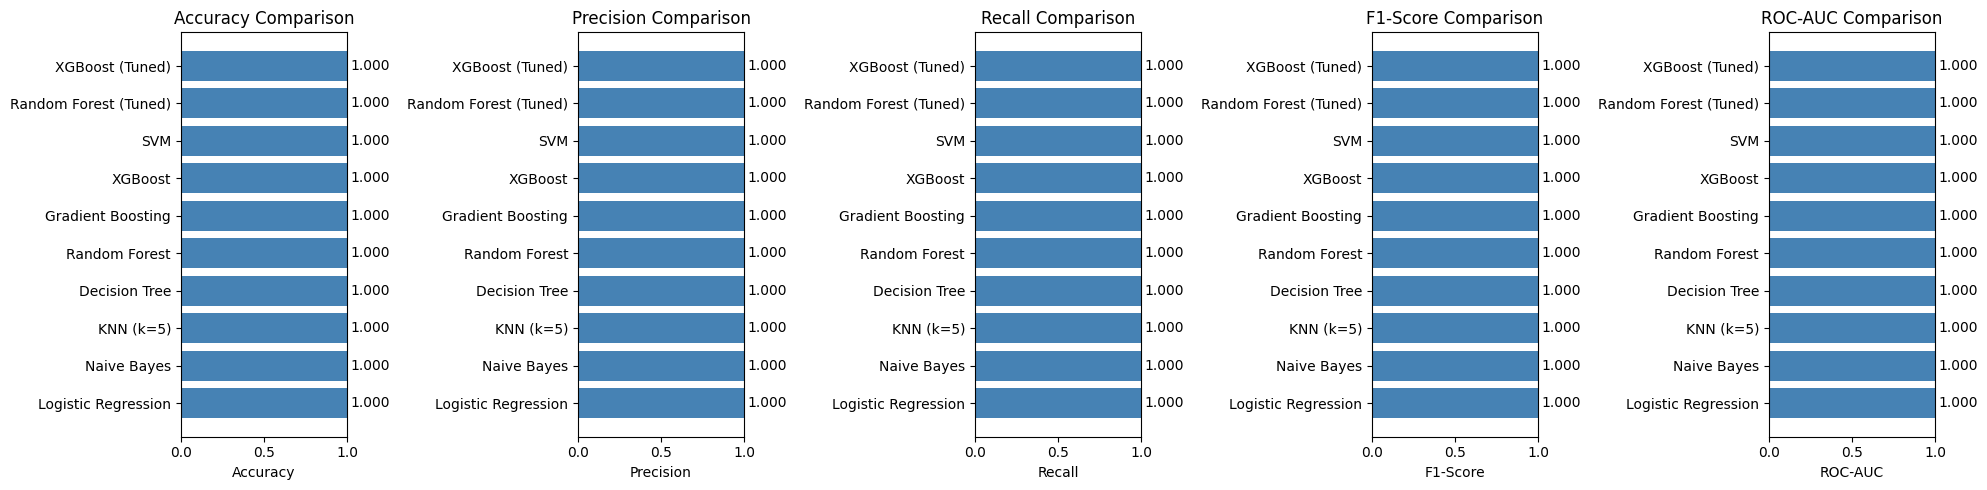

In [282]:
# Bar plot of metrics
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, metric in enumerate(metrics):
    evaluation_df_sorted = evaluation_df.sort_values(metric, ascending=False)
    axes[idx].barh(evaluation_df_sorted['Model'], evaluation_df_sorted[metric], color='steelblue')
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_xlim([0, 1])
    for i, v in enumerate(evaluation_df_sorted[metric]):
        axes[idx].text(v + 0.02, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()


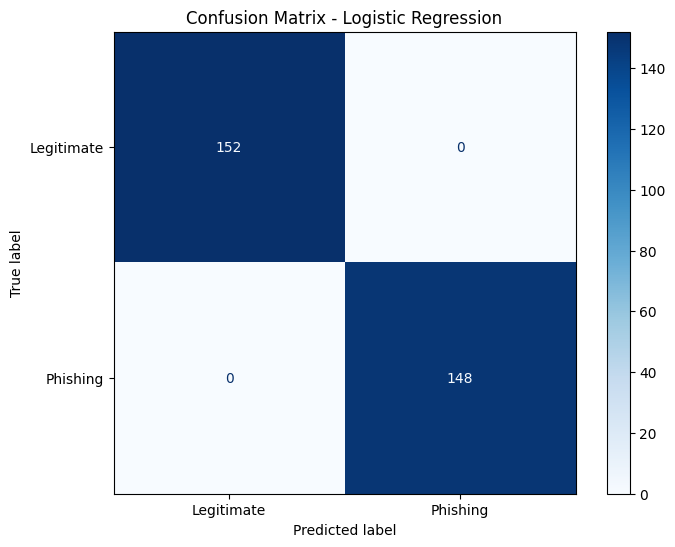


Confusion Matrix Interpretation:
True Negatives (TN):  152 - Legitimate emails correctly identified
False Positives (FP): 0 - Legitimate emails incorrectly flagged as phishing
False Negatives (FN): 0 - Phishing emails that went undetected
True Positives (TP):  148 - Phishing emails correctly identified

False Positive Rate: 0.0000 (0.00%)
False Negative Rate: 0.0000 (0.00%)

Business Impact:
- 0 legitimate emails would be blocked (user frustration)
- 0 phishing emails would slip through (security risk)


In [283]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get best model (highest F1-Score)
best_model_name = evaluation_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['y_pred']

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN):  {cm[0,0]} - Legitimate emails correctly identified")
print(f"False Positives (FP): {cm[0,1]} - Legitimate emails incorrectly flagged as phishing")
print(f"False Negatives (FN): {cm[1,0]} - Phishing emails that went undetected")
print(f"True Positives (TP):  {cm[1,1]} - Phishing emails correctly identified")

# Calculate rates
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"\nFalse Positive Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")
print(f"False Negative Rate: {false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)")
print(f"\nBusiness Impact:")
print(f"- {fp} legitimate emails would be blocked (user frustration)")
print(f"- {fn} phishing emails would slip through (security risk)")


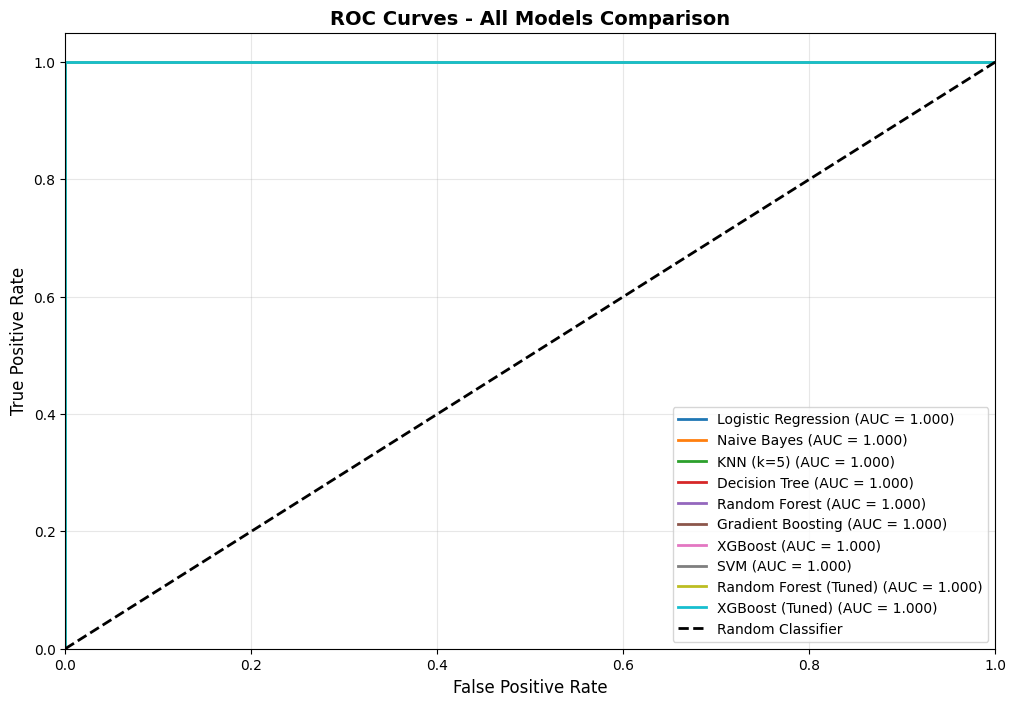

In [284]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for name, result in results.items():
    model = result['model']
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()



Feature Coefficients - Logistic Regression:
             Feature  Coefficient  Abs_Coefficient
has_urgency_keywords     2.264779         2.264779
      subject_length     1.628547         1.628547
       urgency_score     1.560285         1.560285
     spelling_errors     1.299200         1.299200
  email_length_words    -0.992675         0.992675
            has_link     0.122228         0.122228
is_suspicious_domain    -0.031342         0.031342
      has_attachment     0.000093         0.000093


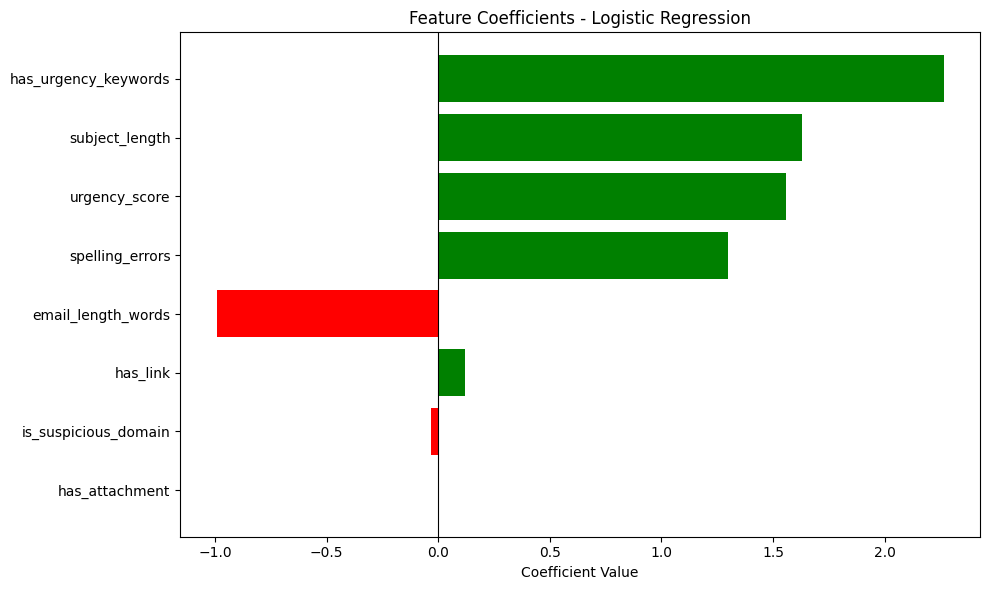

In [285]:
import shap

# Get best model
best_model = results[best_model_name]['model']

# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nFeature Importance - {best_model_name}:")
    print(feature_importance.to_string(index=False))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance - {best_model_name}')
    ax.invert_yaxis()
    
    for i, v in enumerate(feature_importance['Importance']):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center')
    
    plt.tight_layout()
    plt.show()

# For Logistic Regression - coefficients
elif hasattr(best_model, 'coef_'):
    coefficients = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': best_model.coef_[0],
        'Abs_Coefficient': np.abs(best_model.coef_[0])
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print(f"\nFeature Coefficients - {best_model_name}:")
    print(coefficients.to_string(index=False))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['red' if x < 0 else 'green' for x in coefficients['Coefficient']]
    ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
    ax.set_xlabel('Coefficient Value')
    ax.set_title(f'Feature Coefficients - {best_model_name}')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()



Permutation Importance:
             Feature  Importance      Std
has_urgency_keywords    0.005333 0.001633
            has_link    0.000000 0.000000
      has_attachment    0.000000 0.000000
       urgency_score    0.000000 0.000000
     spelling_errors    0.000000 0.000000
  email_length_words    0.000000 0.000000
is_suspicious_domain    0.000000 0.000000
      subject_length    0.000000 0.000000


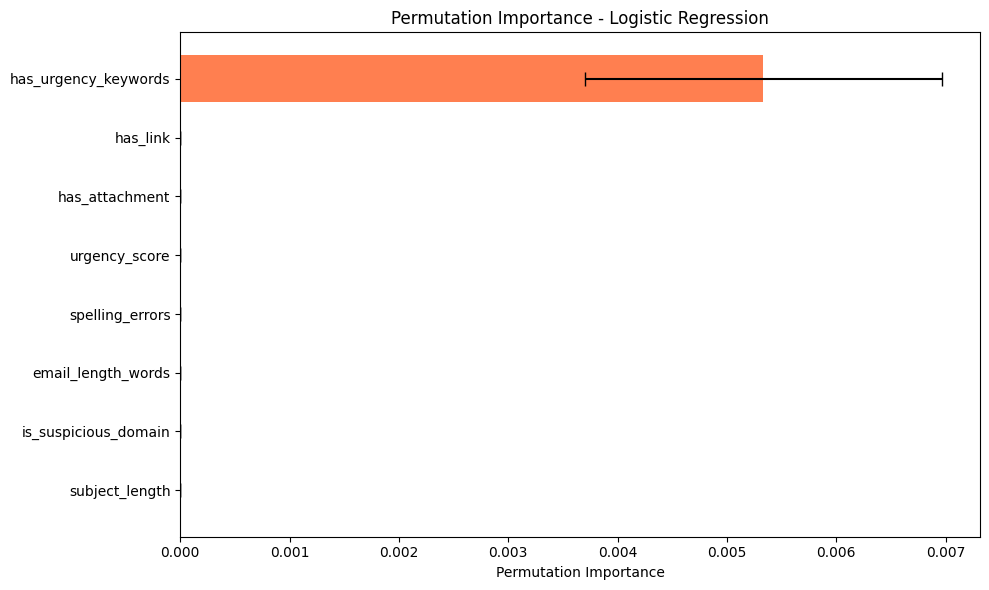

In [286]:
from sklearn.inspection import permutation_importance
import warnings

# Calculate permutation importance sequentially under a warnings filter
# This prevents parallel worker warnings from escaping to the console
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    perm_importance = permutation_importance(
        best_model, X_test, y_test, 
        n_repeats=10, 
        random_state=42, 
        n_jobs=1  # Run sequentially to ensure warnings filter is respected
    )

perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nPermutation Importance:")
print(perm_importance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], 
        xerr=perm_importance_df['Std'], color='coral', capsize=5)
ax.set_xlabel('Permutation Importance')
ax.set_title(f'Permutation Importance - {best_model_name}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


100%|██████████| 100/100 [00:00<00:00, 491.61it/s]


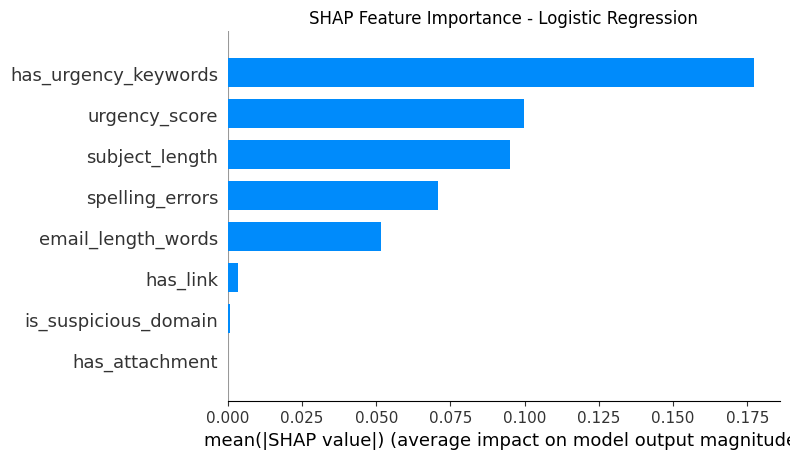

In [287]:
# Install: pip install shap

# Create SHAP explainer
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    
    # Summary plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
    # Detailed summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
else:
    # For other models, use Kernel SHAP
    explainer = shap.KernelExplainer(best_model.predict, X_test.iloc[:100])
    shap_values = explainer.shap_values(X_test.iloc[:100])
    
    shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()


In [288]:
# Get misclassified emails
y_pred_best = results[best_model_name]['y_pred']
misclassified = X_test[(y_test != y_pred_best).values]
misclassified_actual = y_test[(y_test != y_pred_best).values]
misclassified_pred = y_pred_best[(y_test != y_pred_best).values]

print(f"\nTotal Misclassifications: {len(misclassified)}")
print(f"Accuracy of best model: {accuracy_score(y_test, y_pred_best):.4f}")

# False Positives (Legitimate flagged as Phishing)
false_positives = misclassified[(misclassified_actual == 0) & (misclassified_pred == 1)]
print(f"\nFalse Positives: {len(false_positives)}")
if len(false_positives) > 0:
    print("False Positive characteristics:")
    print(false_positives.describe())

# False Negatives (Phishing not detected)
false_negatives = misclassified[(misclassified_actual == 1) & (misclassified_pred == 0)]
print(f"\nFalse Negatives: {len(false_negatives)}")
if len(false_negatives) > 0:
    print("False Negative characteristics:")
    print(false_negatives.describe())



Total Misclassifications: 0
Accuracy of best model: 1.0000

False Positives: 0

False Negatives: 0


In [289]:
# Analyze feature patterns in phishing vs. legitimate
print("\n" + "="*70)
print("BUSINESS INSIGHTS - PHISHING vs. LEGITIMATE EMAILS")
print("="*70)

for feature in X.columns:
    phishing_mean = df[df['is_phishing'] == 1][feature].mean()
    legitimate_mean = df[df['is_phishing'] == 0][feature].mean()
    
    print(f"\n{feature}:")
    print(f"  Phishing emails:    {phishing_mean:.2f}")
    print(f"  Legitimate emails:  {legitimate_mean:.2f}")
    print(f"  Difference:         {abs(phishing_mean - legitimate_mean):.2f}")
    
    if phishing_mean > legitimate_mean:
        print(f"  → Phishing emails have HIGHER {feature}")
    else:
        print(f"  → Legitimate emails have HIGHER {feature}")



BUSINESS INSIGHTS - PHISHING vs. LEGITIMATE EMAILS

has_link:
  Phishing emails:    0.74
  Legitimate emails:  0.52
  Difference:         0.22
  → Phishing emails have HIGHER has_link

has_attachment:
  Phishing emails:    0.52
  Legitimate emails:  0.50
  Difference:         0.02
  → Phishing emails have HIGHER has_attachment

urgency_score:
  Phishing emails:    8.49
  Legitimate emails:  3.03
  Difference:         5.45
  → Phishing emails have HIGHER urgency_score

spelling_errors:
  Phishing emails:    6.46
  Legitimate emails:  1.03
  Difference:         5.43
  → Phishing emails have HIGHER spelling_errors

email_length_words:
  Phishing emails:    70.63
  Legitimate emails:  192.86
  Difference:         122.23
  → Legitimate emails have HIGHER email_length_words

is_suspicious_domain:
  Phishing emails:    0.58
  Legitimate emails:  0.59
  Difference:         0.01
  → Legitimate emails have HIGHER is_suspicious_domain

subject_length:
  Phishing emails:    3.40
  Legitimate emai


Risk Score Distribution:
Risk_Level
Low       152
High      148
Medium      0
Name: count, dtype: int64


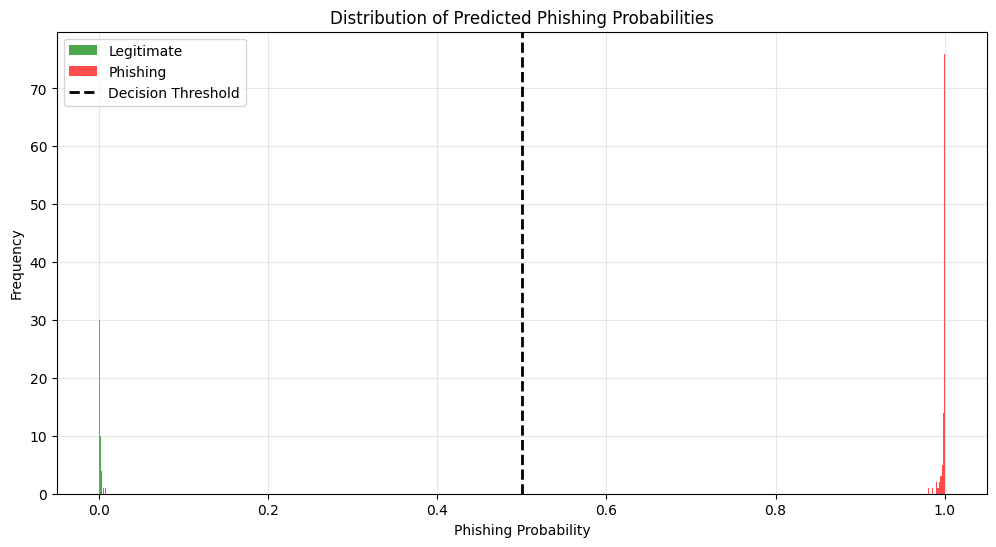

In [290]:
# Get probabilities from best model
y_proba_best = best_model.predict_proba(X_test)[:, 1]

# Create risk score dataframe
risk_analysis = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Phishing_Probability': y_proba_best,
    'Risk_Level': pd.cut(y_proba_best, bins=[0, 0.3, 0.7, 1.0], 
                         labels=['Low', 'Medium', 'High'])
})

print("\nRisk Score Distribution:")
print(risk_analysis['Risk_Level'].value_counts())

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(y_proba_best[y_test == 0], bins=30, label='Legitimate', alpha=0.7, color='green')
ax.hist(y_proba_best[y_test == 1], bins=30, label='Phishing', alpha=0.7, color='red')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax.set_xlabel('Phishing Probability')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Predicted Phishing Probabilities')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [291]:
from sklearn.pipeline import Pipeline
from joblib import dump, load

# Create full pipeline (preprocessing + model)
# Fit the pipeline on RAW training data to ensure scaling works properly in production
production_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

# Retrain on full training data (using raw data)
production_pipeline.fit(X_train_raw, y_train)

# Test pipeline performance on raw test set
y_pred_pipeline = production_pipeline.predict(X_test_raw)
y_proba_pipeline = production_pipeline.predict_proba(X_test_raw)[:, 1]

print("Pipeline Performance (should match best model):")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_pipeline):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_pipeline):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_pipeline):.4f}")

# Save pipeline for deployment
dump(production_pipeline, 'phishing_detection_model.joblib')
print("\nModel saved as 'phishing_detection_model.joblib'")


Pipeline Performance (should match best model):
Accuracy:  1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Model saved as 'phishing_detection_model.joblib'


In [292]:
def predict_phishing_email(features_dict):
    """
    Predict if an email is phishing
    
    Parameters:
    -----------
    features_dict : dict
        Dictionary with raw features
    """
    # Convert to dataframe
    features_df = pd.DataFrame([features_dict])
    
    # Predict
    prediction = production_pipeline.predict(features_df)[0]
    probability = production_pipeline.predict_proba(features_df)[0][1]
    
    return {
        'is_phishing': bool(prediction),
        'phishing_probability': float(probability),
        'confidence': 'High' if probability > 0.8 or probability < 0.2 else 'Medium'
    }

# Example usage (raw values)
test_email = {
    'has_link': 1,
    'has_attachment': 0,
    'urgency_score': 8,
    'spelling_errors': 3,
    'email_length_words': 70,
    'is_suspicious_domain': 1,
    'subject_length': 10,
    'has_urgency_keywords': 1
}

result = predict_phishing_email(test_email)
print(f"\nExample Prediction:")
print(f"Is Phishing: {result['is_phishing']}")
print(f"Probability: {result['phishing_probability']:.4f}")
print(f"Confidence: {result['confidence']}")



Example Prediction:
Is Phishing: True
Probability: 1.0000
Confidence: High


In [293]:
def predict_batch(new_emails_df):
    """
    Predict phishing for multiple emails at once
    """
    predictions = production_pipeline.predict(new_emails_df)
    probabilities = production_pipeline.predict_proba(new_emails_df)[:, 1]
    
    results_df = pd.DataFrame({
        'is_phishing': predictions,
        'phishing_probability': probabilities,
        'risk_level': pd.cut(probabilities, bins=[0, 0.3, 0.7, 1.0], 
                            labels=['Low', 'Medium', 'High'])
    })
    
    return results_df

# Example: Predict on RAW test set
batch_predictions = predict_batch(X_test_raw)
print("Batch Predictions (first 10):")
print(batch_predictions.head(10))

# Summary statistics
print("\nPrediction Summary:")
print(batch_predictions['risk_level'].value_counts())
print(f"\nAverage phishing probability: {batch_predictions['phishing_probability'].mean():.4f}")


Batch Predictions (first 10):
   is_phishing  phishing_probability risk_level
0            0              0.000159        Low
1            1              0.993218       High
2            1              0.995661       High
3            0              0.001136        Low
4            0              0.004208        Low
5            0              0.007742        Low
6            1              0.999351       High
7            1              0.999942       High
8            1              0.999055       High
9            0              0.001057        Low

Prediction Summary:
risk_level
Low       152
High      148
Medium      0
Name: count, dtype: int64

Average phishing probability: 0.4933


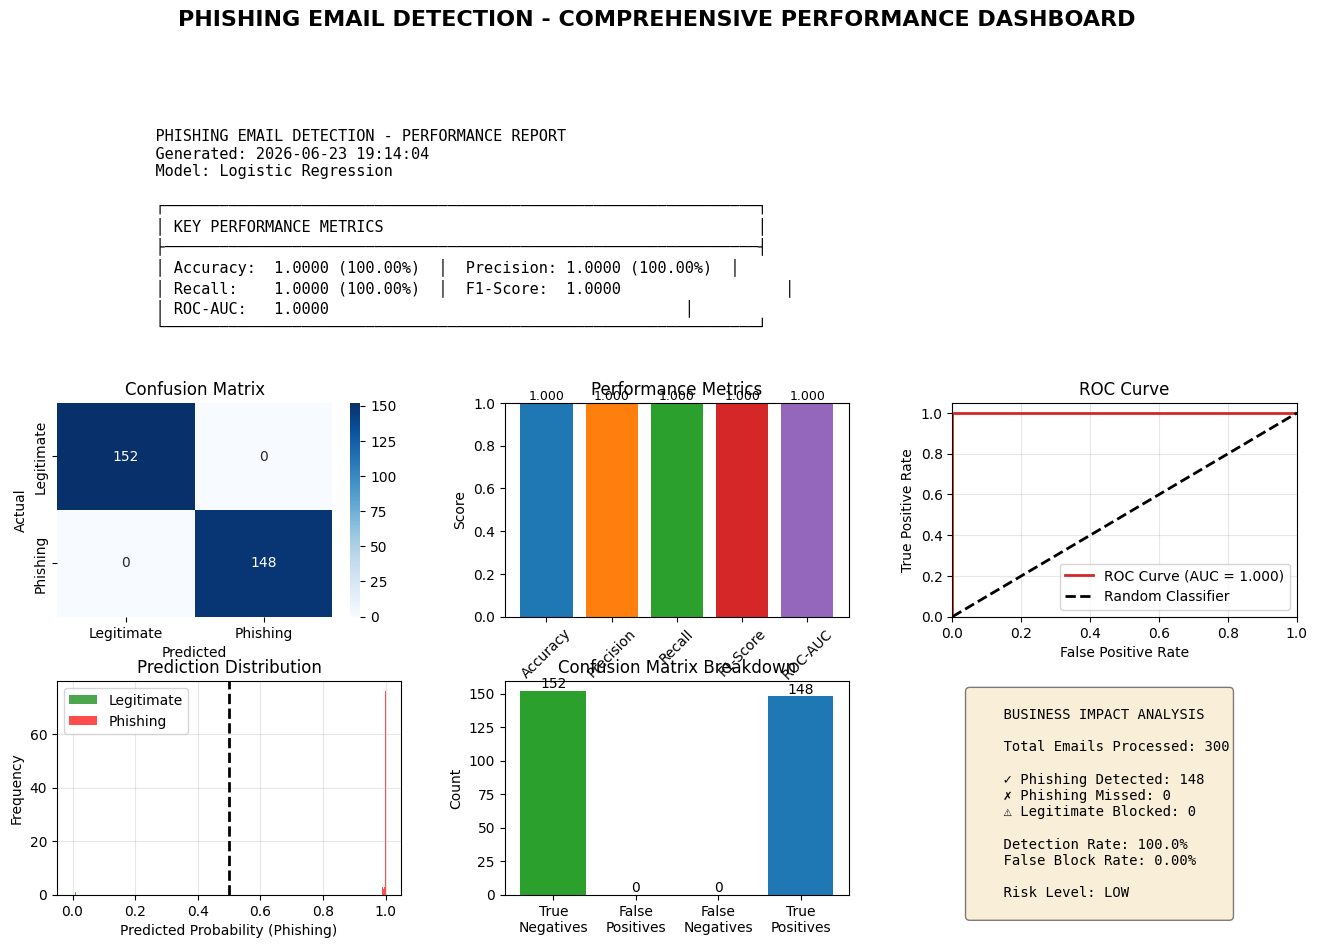

In [294]:
import matplotlib.patches as mpatches
from datetime import datetime

def generate_performance_report(y_true, y_pred, y_proba, report_date=None):
    """
    Generate comprehensive performance report
    """
    
    if report_date is None:
        report_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Key Metrics
    ax1 = fig.add_subplot(gs[0, :])
    ax1.axis('off')
    
    metrics_text = f"""
    PHISHING EMAIL DETECTION - PERFORMANCE REPORT
    Generated: {report_date}
    Model: {best_model_name}
    
    ┌─────────────────────────────────────────────────────────────────┐
    │ KEY PERFORMANCE METRICS                                         │
    ├─────────────────────────────────────────────────────────────────┤
    │ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)  │  Precision: {precision:.4f} ({precision*100:.2f}%)  │
    │ Recall:    {recall:.4f} ({recall*100:.2f}%)  │  F1-Score:  {f1:.4f}                  │
    │ ROC-AUC:   {roc_auc:.4f}                                       │
    └─────────────────────────────────────────────────────────────────┘
    """
    
    ax1.text(0.05, 0.5, metrics_text, fontsize=11, family='monospace',
             verticalalignment='center', transform=ax1.transAxes)
    
    # 2. Confusion Matrix
    ax2 = fig.add_subplot(gs[1, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, 
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    ax2.set_ylabel('Actual')
    ax2.set_xlabel('Predicted')
    ax2.set_title('Confusion Matrix')
    
    # 3. Metrics Comparison
    ax3 = fig.add_subplot(gs[1, 1])
    metrics_values = [accuracy, precision, recall, f1, roc_auc]
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    bars = ax3.bar(metrics_names, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    ax3.set_ylim([0, 1])
    ax3.set_ylabel('Score')
    ax3.set_title('Performance Metrics')
    ax3.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, metrics_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 4. ROC Curve
    ax4 = fig.add_subplot(gs[1, 2])
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax4.plot(fpr, tpr, lw=2, color='#d62728', label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax4.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    ax4.set_xlabel('False Positive Rate')
    ax4.set_ylabel('True Positive Rate')
    ax4.set_title('ROC Curve')
    ax4.legend(loc="lower right")
    ax4.grid(alpha=0.3)
    
    # 5. Prediction Distribution
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.hist(y_proba[y_true == 0], bins=30, label='Legitimate', alpha=0.7, color='green')
    ax5.hist(y_proba[y_true == 1], bins=30, label='Phishing', alpha=0.7, color='red')
    ax5.axvline(x=0.5, color='black', linestyle='--', linewidth=2)
    ax5.set_xlabel('Predicted Probability (Phishing)')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Prediction Distribution')
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # 6. Error Analysis
    ax6 = fig.add_subplot(gs[2, 1])
    error_types = ['True\nNegatives', 'False\nPositives', 'False\nNegatives', 'True\nPositives']
    error_values = [tn, fp, fn, tp]
    colors_err = ['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4']
    bars = ax6.bar(error_types, error_values, color=colors_err)
    ax6.set_ylabel('Count')
    ax6.set_title('Confusion Matrix Breakdown')
    for bar, val in zip(bars, error_values):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{val}', ha='center', va='bottom', fontsize=10)
    
    # 7. Business Impact
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')
    
    total_emails = len(y_true)
    phishing_caught = tp
    phishing_missed = fn
    false_blocked = fp
    
    impact_text = f"""
    BUSINESS IMPACT ANALYSIS
    
    Total Emails Processed: {total_emails}
    
    ✓ Phishing Detected: {phishing_caught}
    ✗ Phishing Missed: {phishing_missed}
    ⚠ Legitimate Blocked: {false_blocked}
    
    Detection Rate: {(phishing_caught/(phishing_caught+phishing_missed)*100):.1f}%
    False Block Rate: {(false_blocked/(false_blocked+tn)*100):.2f}%
    
    Risk Level: {'HIGH' if phishing_missed > 0 else 'LOW'}
    """
    
    ax7.text(0.05, 0.95, impact_text, fontsize=10, family='monospace',
             verticalalignment='top', transform=ax7.transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('PHISHING EMAIL DETECTION - COMPREHENSIVE PERFORMANCE DASHBOARD', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'report_date': report_date
    }

# Generate report
report = generate_performance_report(y_test, y_pred_best, 
                                     production_pipeline.predict_proba(X_test_raw)[:, 1])


Batch 1: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 2: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 3: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 4: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 5: Accuracy=1.0000, F1=1.0000, Status=Normal


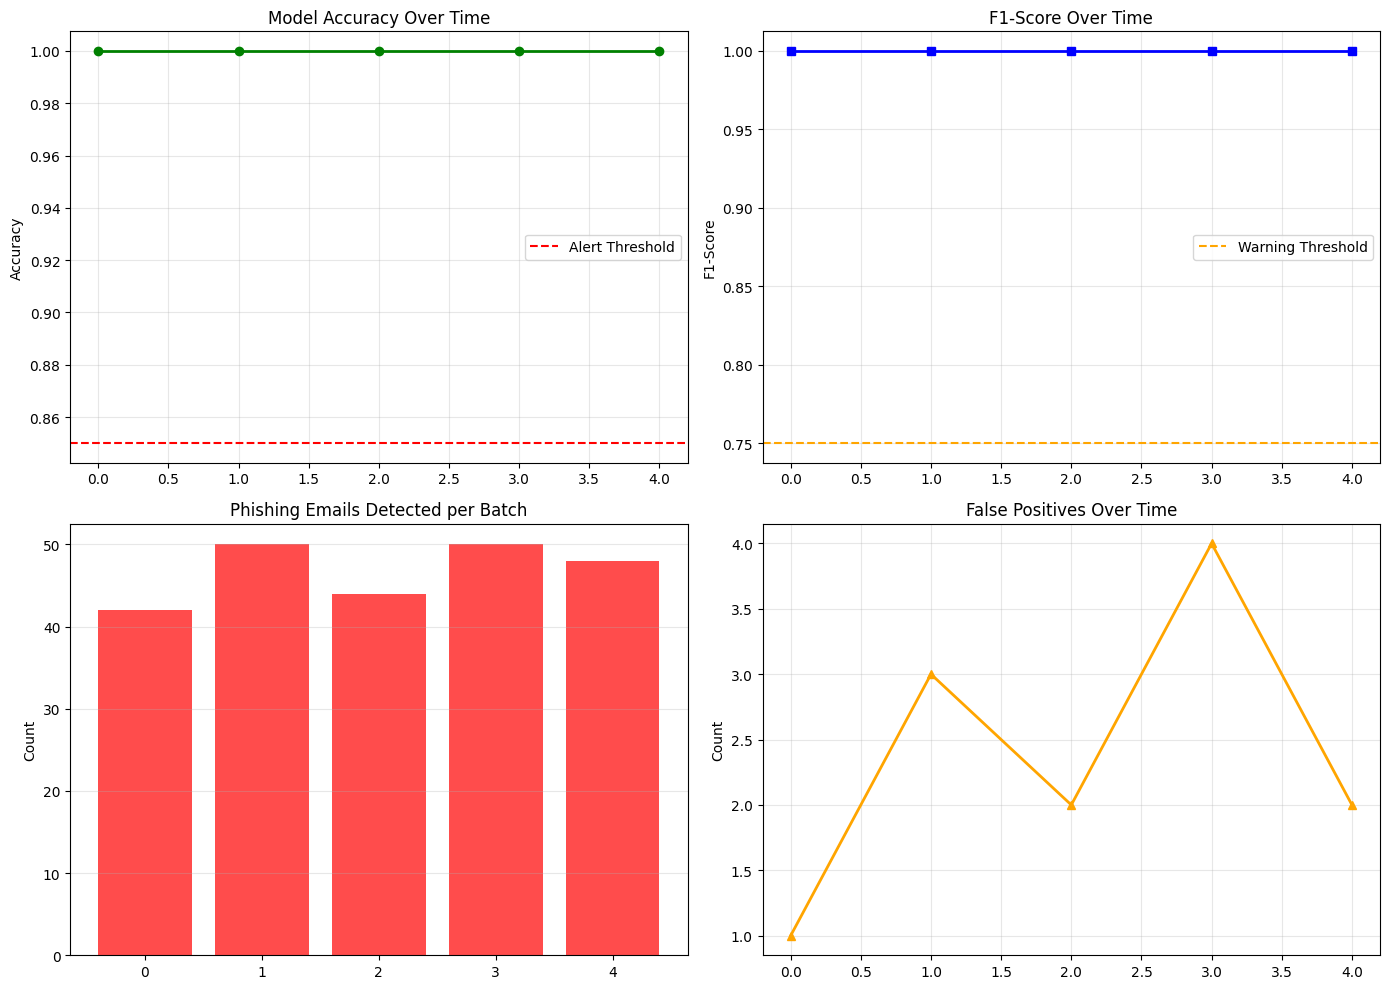

In [295]:
# Simulate monitoring over time
monitoring_history = []

def log_prediction_batch(batch_predictions, batch_actual, timestamp=None):
    """
    Log prediction batch for monitoring
    """
    if timestamp is None:
        timestamp = datetime.now()
    
    batch_accuracy = accuracy_score(batch_actual, batch_predictions['is_phishing'])
    batch_f1 = f1_score(batch_actual, batch_predictions['is_phishing'])
    
    monitoring_history.append({
        'timestamp': timestamp,
        'accuracy': batch_accuracy,
        'f1_score': batch_f1,
        'total_predictions': len(batch_predictions),
        'phishing_detected': batch_predictions['is_phishing'].sum(),
        'false_positives': ((batch_predictions['is_phishing'] == 1) & (batch_actual == 0)).sum()
    })
    
    return {
        'batch_accuracy': batch_accuracy,
        'batch_f1': batch_f1,
        'status': 'Normal' if batch_f1 > 0.75 else 'Warning' if batch_f1 > 0.6 else 'Alert'
    }

# Simulate multiple batches
for i in range(5):
    batch_size = 100
    batch_indices = np.random.choice(len(X_test_raw), batch_size, replace=False)
    
    batch_X = X_test_raw.iloc[batch_indices]
    batch_y = y_test.iloc[batch_indices]
    
    batch_pred = predict_batch(batch_X)
    status = log_prediction_batch(batch_pred, batch_y)
    
    print(f"Batch {i+1}: Accuracy={status['batch_accuracy']:.4f}, F1={status['batch_f1']:.4f}, Status={status['status']}")

# Visualize monitoring history
monitoring_df = pd.DataFrame(monitoring_history)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy trend
axes[0, 0].plot(range(len(monitoring_df)), monitoring_df['accuracy'], marker='o', color='green', linewidth=2)
axes[0, 0].axhline(y=0.85, color='red', linestyle='--', label='Alert Threshold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Model Accuracy Over Time')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# F1-Score trend
axes[0, 1].plot(range(len(monitoring_df)), monitoring_df['f1_score'], marker='s', color='blue', linewidth=2)
axes[0, 1].axhline(y=0.75, color='orange', linestyle='--', label='Warning Threshold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_title('F1-Score Over Time')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Phishing detected per batch
axes[1, 0].bar(range(len(monitoring_df)), monitoring_df['phishing_detected'], color='red', alpha=0.7)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Phishing Emails Detected per Batch')
axes[1, 0].grid(alpha=0.3, axis='y')

# False positives trend
axes[1, 1].plot(range(len(monitoring_df)), monitoring_df['false_positives'], marker='^', color='orange', linewidth=2)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('False Positives Over Time')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [296]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import joblib

def retrain_model(new_training_data, new_labels, retrain_threshold=0.05):
    """
    Retrain model if performance degrades using raw features
    """
    # Combine with historical raw data
    combined_X = pd.concat([X_train_raw, new_training_data], ignore_index=True)
    combined_y = pd.concat([y_train, new_labels], ignore_index=True)

    # Check current performance
    current_f1 = f1_score(y_test, y_pred_best)

    # Scale data for retraining model (since RandomForestClassifier inside production pipeline expects scaled values)
    scaler_retrain = StandardScaler()
    combined_X_scaled = pd.DataFrame(scaler_retrain.fit_transform(combined_X), columns=combined_X.columns)
    X_test_scaled = pd.DataFrame(scaler_retrain.transform(X_test_raw), columns=combined_X.columns)

    # Train new model
    new_model = RandomForestClassifier(n_estimators=150, random_state=42)
    new_model.fit(combined_X_scaled, combined_y)

    # Evaluate new model
    new_predictions = new_model.predict(X_test_scaled)
    new_f1 = f1_score(y_test, new_predictions)

    # Compare performance
    f1_change = (new_f1 - current_f1) / current_f1 if current_f1 > 0 else 0

    print(f"Current F1-Score: {current_f1:.4f}")
    print(f"New F1-Score: {new_f1:.4f}")
    print(f"Change: {f1_change*100:.2f}%")

    if f1_change < -retrain_threshold:
        print("⚠ Performance degradation detected! Retraining recommended.")
        return False, new_model, new_f1
    elif f1_change > 0.02:
        print("✓ Model improved! Accepting new model.")
        return True, new_model, new_f1
    else:
        print("→ Minimal change. Current model retained.")
        current_model = None
        if 'production_pipeline' in globals():
            current_model = production_pipeline.named_steps['model']
        elif 'best_model' in globals():
            current_model = best_model
        return False, current_model, current_f1

# Ensure raw splits exist
if 'X_train_raw' not in globals():
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

np.random.seed(42)

# Define sample size for retraining data if not already available
new_size = min(100, len(X_test_raw))

new_X = X_test_raw.sample(n=new_size, random_state=42).copy()
new_y = y_test.sample(n=new_size, random_state=42).copy()

should_update, retrained_model, new_f1_score = retrain_model(new_X, new_y)

if should_update:
    # Create new pipeline
    new_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', retrained_model)
    ])
    joblib.dump(new_pipeline, 'phishing_detection_model_v2.joblib')
    print("\n✓ Model saved as 'phishing_detection_model_v2.joblib'")


Current F1-Score: 1.0000
New F1-Score: 1.0000
Change: 0.00%
→ Minimal change. Current model retained.


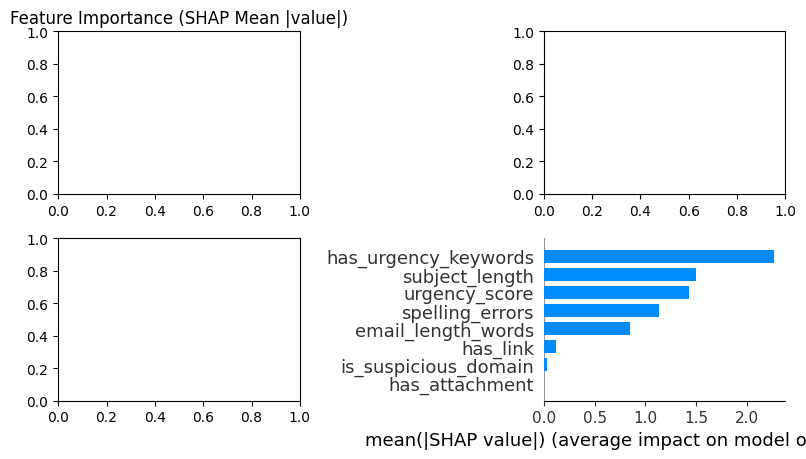

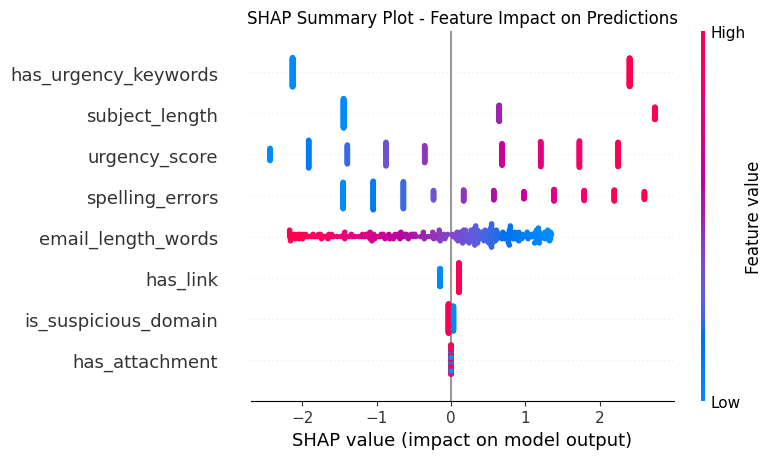

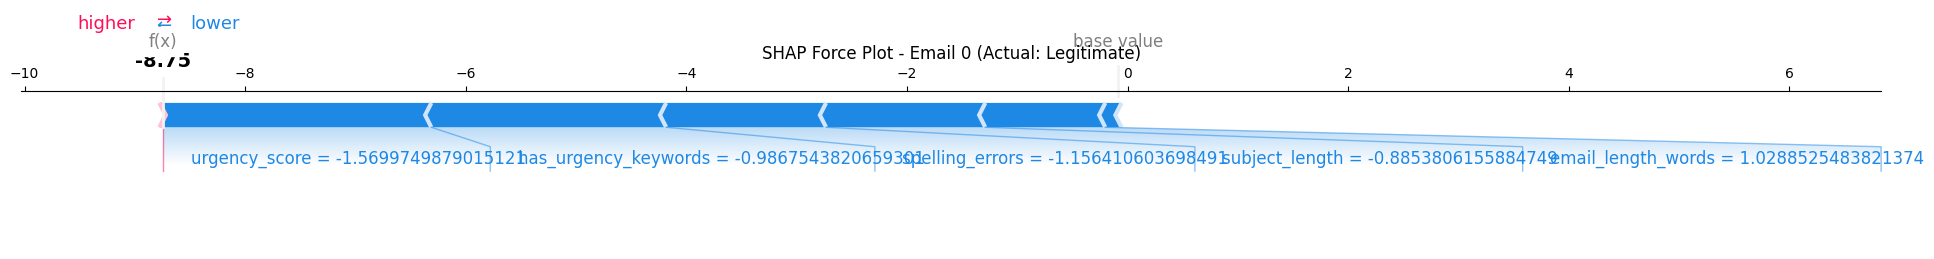

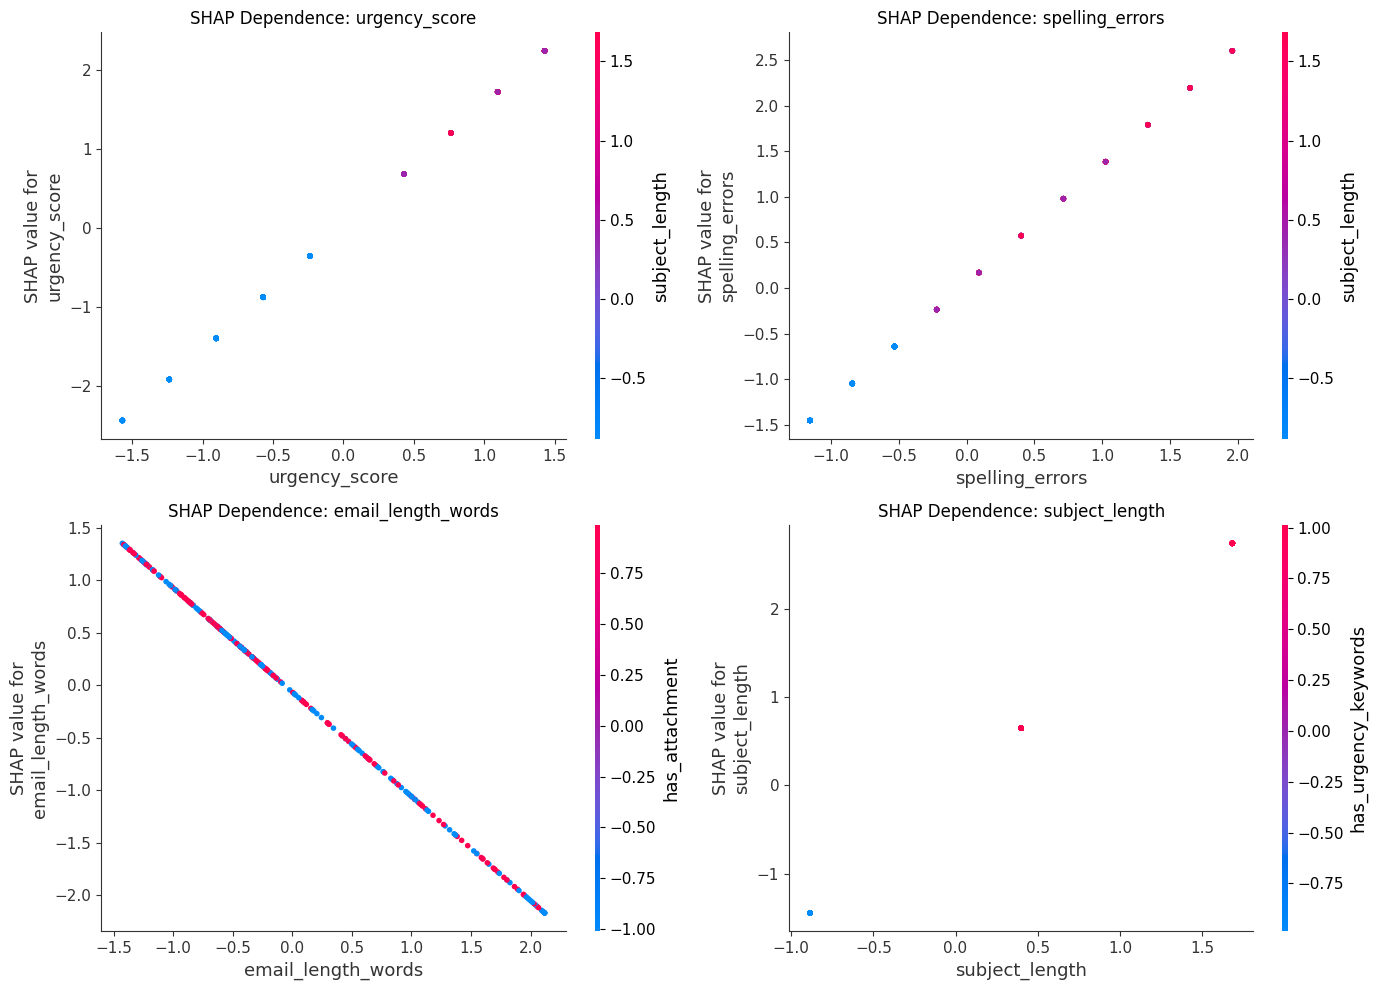

In [297]:
# Install: pip install shap

import shap

# Create SHAP explainer
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
elif best_model_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, X_test, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_test)
else:
    explainer = shap.KernelExplainer(best_model.predict_proba, X_test.sample(n=min(100, len(X_test)), random_state=42))
    shap_values = explainer.shap_values(X_test)

def get_positive_class_shap(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]
    if shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values

shap_values_phishing = get_positive_class_shap(shap_values)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and len(expected_value) > 1:
    expected_value = expected_value[1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Summary Plot (Bar)
ax1 = axes[0, 0]
shap.summary_plot(shap_values_phishing, X_test, plot_type="bar", show=False, max_display=10)
plt.sca(ax1)
plt.title('Feature Importance (SHAP Mean |value|)')
plt.tight_layout()

# 2. Summary Plot (Beeswarm)
fig2 = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_phishing, X_test, show=False, max_display=10)
plt.title('SHAP Summary Plot - Feature Impact on Predictions')
plt.tight_layout()
plt.show()

# 3. Force Plot for individual prediction
sample_idx = 0
shap.force_plot(expected_value, shap_values_phishing[sample_idx], X_test.iloc[sample_idx], matplotlib=True, show=False)
plt.title(f'SHAP Force Plot - Email {sample_idx} (Actual: {"Phishing" if y_test.iloc[sample_idx] else "Legitimate"})')
plt.tight_layout()
plt.show()

# 4. Dependence Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_features = ['urgency_score', 'spelling_errors', 'email_length_words', 'subject_length']

for idx, feature in enumerate(top_features):
    ax = axes[idx // 2, idx % 2]
    shap.dependence_plot(feature, shap_values_phishing, X_test, show=False, ax=ax)
    ax.set_title(f'SHAP Dependence: {feature}')

plt.tight_layout()
plt.show()
